# 02 — Logistic Regression from Scratch

**Goal:** code every piece of logistic regression yourself — sigmoid, predict, cost (log loss), gradient, gradient descent, decision boundary. No sklearn, no shortcuts.

This is your first time coding this concept, so a few cells here have a bit more guidance than usual (a hint comment or a smaller helper step). Everything else follows the same pattern as `01_linear_regression.ipynb`: signature + docstring, then a sanity check cell with a hard `assert`.

**Structure of this notebook:**
1. Setup + tiny toy dataset
2. Sigmoid function
3. Single-feature logistic regression (predict → cost → gradient → gradient descent)
4. Multi-feature (vectorized) logistic regression
5. Decision boundary + accuracy on a real-ish dataset
6. Reference solutions (at the very bottom — don't peek early)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


---
## Part 1 — The Sigmoid Function

Logistic regression's whole trick is squashing a linear output into a probability between 0 and 1:

$$g(z) = \frac{1}{1 + e^{-z}}$$

This one function is the reason logistic regression can do classification at all. Get comfortable with it before anything else.


In [2]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    Args:
        z (ndarray or scalar): input value(s), any shape

    Returns:
        g (ndarray or scalar): sigmoid(z), same shape as z, values in (0, 1)
    """
    # TODO: implement
    # hint: np.exp(-z) works elementwise on arrays too
    return 1 / (1 + np.exp(-z))


In [3]:
# Sanity check
print("sigmoid(0):", sigmoid(0))
print("Expected:   0.5")
assert np.isclose(sigmoid(0), 0.5)

z_test = np.array([-10, 0, 10])
g = sigmoid(z_test)
print("\nsigmoid([-10, 0, 10]):", g)
print("Expected:               [~0.0000, 0.5, ~1.0000]")
assert np.isclose(g[0], 0.0, atol=1e-4)
assert np.isclose(g[1], 0.5)
assert np.isclose(g[2], 1.0, atol=1e-4)
print("sigmoid passed!")


sigmoid(0): 0.5
Expected:   0.5

sigmoid([-10, 0, 10]): [0.  0.5 1. ]
Expected:               [~0.0000, 0.5, ~1.0000]
sigmoid passed!


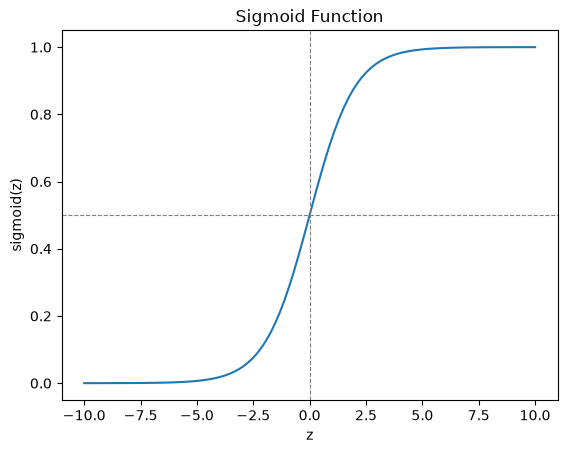

In [4]:
# Quick visual: this S-shape is what "squashes" any real number into (0,1)
z_range = np.linspace(-10, 10, 100)
plt.plot(z_range, sigmoid(z_range))
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.show()


---
## Part 2 — Single-Feature Logistic Regression

Model: $f_{w,b}(x) = g(wx + b) = \frac{1}{1 + e^{-(wx+b)}}$

The output is a **probability** — "probability that y=1 given x". We'll use a tiny toy dataset: x below some threshold is class 0, above it is class 1.


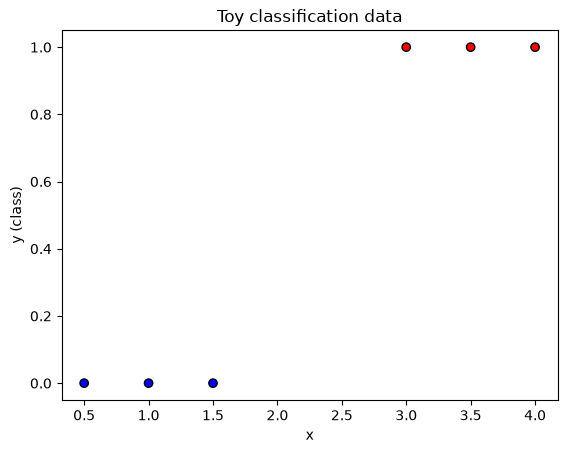

In [5]:
# Toy dataset: single feature, binary labels
x_train = np.array([0.5, 1.0, 1.5, 3.0, 3.5, 4.0])
y_train = np.array([0,   0,   0,   1,   1,   1])

plt.scatter(x_train, y_train, c=y_train, cmap='bwr', edgecolor='k')
plt.xlabel("x")
plt.ylabel("y (class)")
plt.title("Toy classification data")
plt.show()


### 2.1 — Predict (forward pass)

$$f_{w,b}(x^{(i)}) = g(w x^{(i)} + b)$$

This should return a probability, not a 0/1 label. Reuse your `sigmoid` function.


In [6]:
def predict_single(x, w, b):
    """
    Compute predicted probabilities for single-feature logistic regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        w (scalar): weight parameter
        b (scalar): bias parameter

    Returns:
        y_hat (ndarray (m,)): predicted probabilities, values in (0,1)
    """
    # TODO: implement
    # hint: compute z = w*x + b, then pass z through sigmoid

    return sigmoid(x * w + b)

In [7]:
# Sanity check
y_hat = predict_single(x_train, w=0.0, b=0.0)
print("Your output (w=0,b=0):", y_hat)
print("Expected:              [0.5 0.5 0.5 0.5 0.5 0.5]  (z=0 everywhere -> sigmoid=0.5)")
assert np.allclose(y_hat, 0.5)

y_hat2 = predict_single(np.array([2.0]), w=1.0, b=0.0)
print("\nYour output (x=2, w=1, b=0):", y_hat2)
print("Expected:                    ", sigmoid(np.array([2.0])))
assert np.allclose(y_hat2, sigmoid(np.array([2.0])))
print("predict_single passed!")


Your output (w=0,b=0): [0.5 0.5 0.5 0.5 0.5 0.5]
Expected:              [0.5 0.5 0.5 0.5 0.5 0.5]  (z=0 everywhere -> sigmoid=0.5)

Your output (x=2, w=1, b=0): [0.8808]
Expected:                     [0.8808]
predict_single passed!


### 2.2 — Cost function (log loss / binary cross-entropy)

$$J(w,b) = -\frac{1}{m}\sum_{i=0}^{m-1}\Big[y^{(i)}\log(f_{w,b}(x^{(i)})) + (1-y^{(i)})\log(1-f_{w,b}(x^{(i)}))\Big]$$

Intuition: if $y^{(i)}=1$, only the first term matters — it heavily penalizes low predicted probability. If $y^{(i)}=0$, only the second term matters — it heavily penalizes high predicted probability.

**Numerical stability tip:** predictions very close to 0 or 1 can make `np.log(0)` blow up to `-inf`. Clip predictions into a safe range before taking the log, e.g. `np.clip(y_hat, 1e-10, 1 - 1e-10)`.


In [ ]:
def compute_cost_single(x, y, w, b):
    """
    Compute log loss (binary cross-entropy) for single-feature logistic regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        y (ndarray (m,)): binary target values (0 or 1)
        w (scalar): weight parameter
        b (scalar): bias parameter

    Returns:
        cost (scalar): average log loss over all examples
    """
    # TODO: implement
    # hint: get y_hat from predict_single, clip it with np.clip(y_hat, 1e-10, 1 - 1e-10)
    # before plugging into the log loss formula

    m = x.shape[0]

    f_x = predict_single(x,w,b)
    np.clip(f_x, 1e-10 , 1 -1e-10)
    loss = y * np.log(f_x) + (1 - y ) * np.log(1 - f_x)
    sum = np.sum(loss)

    return - (sum / m) 

In [14]:
# Sanity check
# With w=0, b=0, every prediction is 0.5, so cost = -log(0.5) = log(2) regardless of labels
cost = compute_cost_single(x_train, y_train, w=0.0, b=0.0)
print("Your cost (w=0,b=0):", cost)
print("Expected:           ", np.log(2))
assert np.isclose(cost, np.log(2), atol=1e-4)
print("compute_cost_single passed!")


Your cost (w=0,b=0): 0.6931471805599453
Expected:            0.6931471805599453
compute_cost_single passed!


### 2.3 — Gradient

The gradient formulas for logistic regression look *identical* to linear regression's — only $f_{w,b}$ is now the sigmoid version instead of the linear one. This is not a coincidence (it falls out of the log-loss + sigmoid combination), but you don't need the derivation to code it.

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{w,b}(x^{(i)}) - y^{(i)})$$


In [15]:
def compute_gradient_single(x, y, w, b):
    """
    Compute gradient for single-feature logistic regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        y (ndarray (m,)): binary target values (0 or 1)
        w (scalar): weight parameter
        b (scalar): bias parameter

    Returns:
        dj_dw (scalar): gradient of cost w.r.t. w
        dj_db (scalar): gradient of cost w.r.t. b
    """
    # TODO: implement
    m = x.shape[0]
    error = predict_single(x,w,b) - y

    dj_dw = np.sum(error * x) / m 
    dj_db = np.sum(error) / m

    return dj_dw,dj_db


In [16]:
# Sanity check
dj_dw, dj_db = compute_gradient_single(x_train, y_train, w=0.0, b=0.0)
print("Your dj_dw, dj_db (w=0,b=0):", dj_dw, dj_db)
print("Expected:                    -0.625 0.0")
assert np.isclose(dj_dw, -0.625, atol=1e-3)
assert np.isclose(dj_db, 0.0, atol=1e-6)
print("compute_gradient_single passed!")


Your dj_dw, dj_db (w=0,b=0): -0.625 0.0
Expected:                    -0.625 0.0
compute_gradient_single passed!


### 2.4 — Gradient Descent

Same update rule as linear regression:

$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$


In [18]:
def gradient_descent_single(x, y, w_init, b_init, alpha, num_iters):
    """
    Run gradient descent for single-feature logistic regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        y (ndarray (m,)): binary target values (0 or 1)
        w_init (scalar): initial weight
        b_init (scalar): initial bias
        alpha (scalar): learning rate
        num_iters (int): number of iterations to run

    Returns:
        w (scalar): final weight after training
        b (scalar): final bias after training
        cost_history (list): cost at every iteration (for plotting)
    """
    # TODO: implement
    # hint: same loop structure as gradient_descent_single from the linear regression lab,
    # just calling compute_gradient_single / compute_cost_single from THIS notebook

    w, b = w_init, b_init
    cost_history = []

    for i in range(num_iters):
        dj_dw , dj_db = compute_gradient_single(x,y,w,b)
        w = w - dj_dw
        b = b - dj_db

        cost_history.append(compute_cost_single(x,y,w,b))

    return w, b, cost_history

Final w, b: 6.9261972360519 -15.289812225577718
Final cost: 0.001985594801578128
Initial cost: 0.5851859633371937
gradient_descent_single passed!


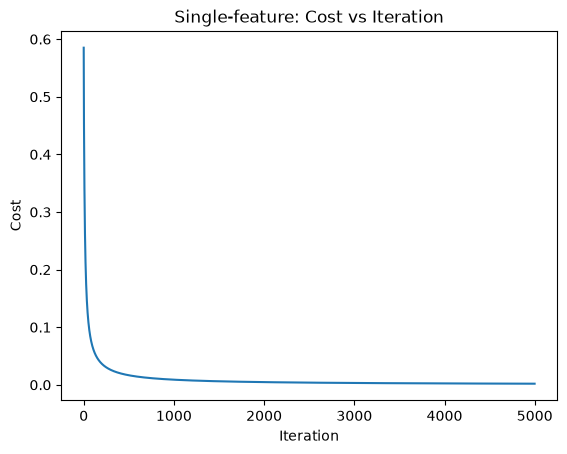

In [19]:
# Sanity check
w_final, b_final, cost_history = gradient_descent_single(
    x_train, y_train, w_init=0.0, b_init=0.0, alpha=0.1, num_iters=5000
)

print("Final w, b:", w_final, b_final)
print("Final cost:", cost_history[-1])
print("Initial cost:", cost_history[0])

assert cost_history[-1] < cost_history[0], "Cost should decrease over training"
assert cost_history[-1] < 0.1, "Cost should be low since this data is linearly separable"
print("gradient_descent_single passed!")

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Single-feature: Cost vs Iteration")
plt.show()


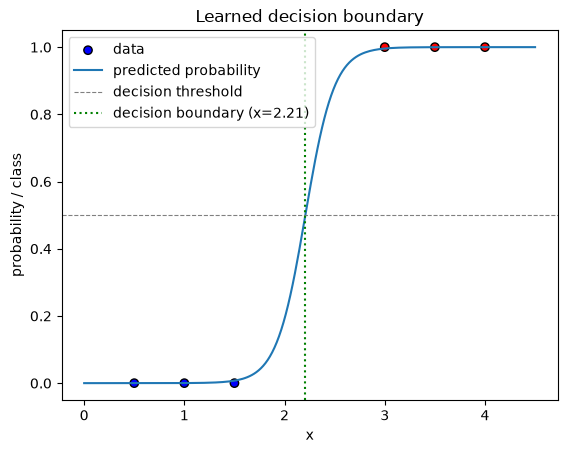

In [21]:
# Visualize the learned decision boundary
x_range = np.linspace(0, 4.5, 200)
y_prob = predict_single(x_range, w_final, b_final)

plt.scatter(x_train, y_train, c=y_train, cmap='bwr', edgecolor='k', label='data')
plt.plot(x_range, y_prob, label='predicted probability')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='decision threshold')
boundary_x = -b_final / w_final
plt.axvline(boundary_x, color='green', linestyle=':', label=f'decision boundary (x={boundary_x:.2f})')
plt.xlabel("x")
plt.ylabel("probability / class")
plt.legend()
plt.title("Learned decision boundary")
plt.show()


---
## Part 3 — Multi-Feature (Vectorized) Logistic Regression

Same generalization as linear regression: $w$ becomes a vector, model is

$$f_{\vec{w},b}(\vec{x}) = g(\vec{w}\cdot\vec{x} + b)$$

Vectorize everything — no loops over features.


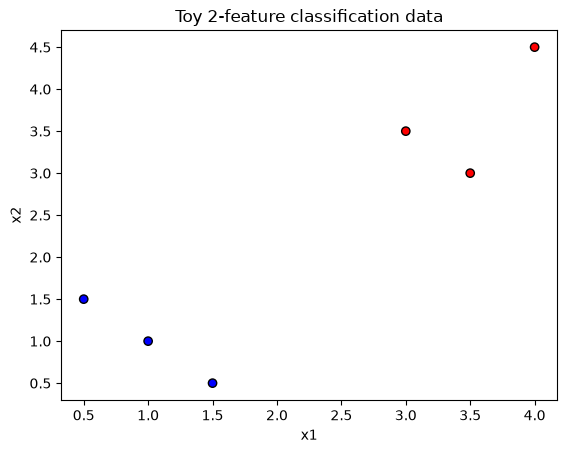

In [22]:
# Toy dataset: 2 features, binary labels (roughly linearly separable)
np.random.seed(1)
X_train = np.array([
    [0.5, 1.5],
    [1.0, 1.0],
    [1.5, 0.5],
    [3.0, 3.5],
    [3.5, 3.0],
    [4.0, 4.5]
])
y_train_multi = np.array([0, 0, 0, 1, 1, 1])

plt.scatter(X_train[:,0], X_train[:,1], c=y_train_multi, cmap='bwr', edgecolor='k')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Toy 2-feature classification data")
plt.show()


### 3.1 — Predict (vectorized)

$$f_{\vec{w},b}(\vec{x}^{(i)}) = g(\vec{w}\cdot\vec{x}^{(i)} + b)$$

For all examples at once: $f = g(X\vec{w} + b)$


In [23]:
def predict_multi(X, w, b):
    """
    Compute predicted probabilities for multi-feature logistic regression, vectorized.

    Args:
        X (ndarray (m,n)): m examples, n features each
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        y_hat (ndarray (m,)): predicted probabilities, values in (0,1)
    """
    # TODO: implement (no loops over examples or features)
    
    return sigmoid(np.dot(X, w) + b)

In [24]:
# Sanity check
w_test = np.array([1.0, 1.0])
b_test = -4.0
y_hat = predict_multi(X_train, w_test, b_test)
expected = sigmoid(X_train @ w_test + b_test)

print("Your output:", y_hat)
print("Expected:   ", expected)
assert np.allclose(y_hat, expected)
print("predict_multi passed!")


Your output: [0.1192 0.1192 0.1192 0.9241 0.9241 0.989 ]
Expected:    [0.1192 0.1192 0.1192 0.9241 0.9241 0.989 ]
predict_multi passed!


### 3.2 — Cost function (vectorized)

Same log loss formula, vectorized. Don't forget the clip trick for numerical stability.


In [37]:
def compute_cost_multi(X, y, w, b):
    """
    Compute log loss for multi-feature logistic regression.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): binary target values (0 or 1)
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        cost (scalar): average log loss over all examples
    """
    # TODO: implement

    f_x = np.clip(predict_multi(X,w,b), 1e-10, 1 - 1e-10 )
    cost = np.sum(y * np.log(f_x) + (1 - y) * (np.log(1 - f_x))) / X.shape[0]

    return -cost

In [38]:
# Sanity check
cost = compute_cost_multi(X_train, y_train_multi, w=np.zeros(2), b=0.0)
print("Your cost (w=0,b=0):", cost)
print("Expected:           ", np.log(2))
assert np.isclose(cost, np.log(2), atol=1e-4)
print("compute_cost_multi passed!")


Your cost (w=0,b=0): 0.6931471805599453
Expected:            0.6931471805599453
compute_cost_multi passed!


### 3.3 — Gradient (vectorized)

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$

Same vectorized pattern as linear regression: error vector, then $X^T \cdot \text{error} / m$.


In [39]:
def compute_gradient_multi(X, y, w, b):
    """
    Compute gradient for multi-feature logistic regression, vectorized.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): binary target values (0 or 1)
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        dj_dw (ndarray (n,)): gradient of cost w.r.t. w
        dj_db (scalar): gradient of cost w.r.t. b
    """
    # TODO: implement (no loops over features)
    
    m = X.shape[0]

    error = predict_multi(X,w,b) - y 

    dj_dw = np.dot(X.T, error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db


In [40]:
# Sanity check
dj_dw, dj_db = compute_gradient_multi(X_train, y_train_multi, w=np.zeros(2), b=0.0)
expected_dj_dw = np.array([-0.625, -0.6667])
expected_dj_db = 0.0

print("Your dj_dw:", dj_dw)
print("Expected:  ", expected_dj_dw)
print("Your dj_db:", dj_db)
print("Expected:  ", expected_dj_db)

assert np.allclose(dj_dw, expected_dj_dw, atol=1e-3)
assert np.isclose(dj_db, expected_dj_db, atol=1e-6)
print("compute_gradient_multi passed!")


Your dj_dw: [-0.625  -0.6667]
Expected:   [-0.625  -0.6667]
Your dj_db: 0.0
Expected:   0.0
compute_gradient_multi passed!


### 3.4 — Gradient Descent (vectorized)


In [41]:
def gradient_descent_multi(X, y, w_init, b_init, alpha, num_iters):
    """
    Run gradient descent for multi-feature logistic regression.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): binary target values (0 or 1)
        w_init (ndarray (n,)): initial weight vector
        b_init (scalar): initial bias
        alpha (scalar): learning rate
        num_iters (int): number of iterations

    Returns:
        w (ndarray (n,)): final weight vector
        b (scalar): final bias
        cost_history (list): cost at every iteration
    """
    # TODO: implement

    cost_history = []
    w, b = w_init, b_init 

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_multi(X,y,w,b) 

        w = w - dj_dw
        b = b - dj_db

        cost_history.append(compute_cost_multi(X,y,w,b))

    return w, b, cost_history

Final w: [3.1384 3.1403]
Final b: -13.025475950984424
Final cost: 0.0007949193206548516
gradient_descent_multi passed!


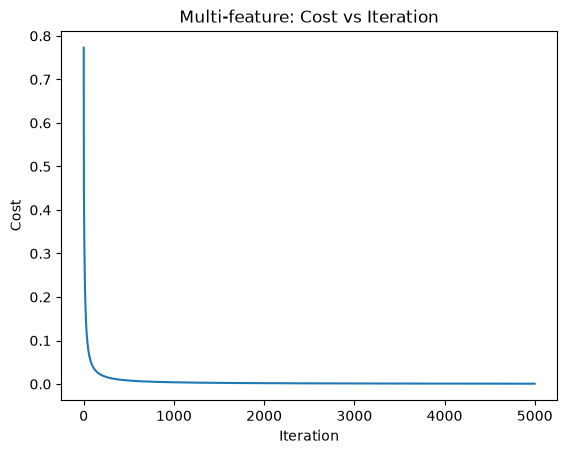

In [42]:
# Sanity check
w_init = np.zeros(2)
w_final, b_final, cost_history = gradient_descent_multi(
    X_train, y_train_multi, w_init, 0.0, alpha=0.5, num_iters=5000
)

print("Final w:", w_final)
print("Final b:", b_final)
print("Final cost:", cost_history[-1])

assert cost_history[-1] < cost_history[0]
assert cost_history[-1] < 0.1
print("gradient_descent_multi passed!")

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Multi-feature: Cost vs Iteration")
plt.show()


---
## Part 4 — Classify and Measure Accuracy on a Bigger Dataset

A probability isn't a class label. To classify, threshold at 0.5:

$$\hat{y}^{(i)} = \begin{cases} 1 & \text{if } f_{\vec{w},b}(\vec{x}^{(i)}) \geq 0.5 \\ 0 & \text{otherwise} \end{cases}$$


In [ ]:
def predict_labels(X, w, b):
    """
    Convert predicted probabilities into binary class labels using a 0.5 threshold.

    Args:
        X (ndarray (m,n)): m examples, n features
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        labels (ndarray (m,)): predicted class labels, 0 or 1 (integers)
    """
    # TODO: implement
    # hint: get probabilities from predict_multi, then threshold at 0.5
    # cast the result to int, e.g. with .astype(int)
    pass


In [ ]:
# Sanity check
labels = predict_labels(X_train, w_final, b_final)
print("Your labels:  ", labels)
print("True labels:  ", y_train_multi)
assert np.array_equal(labels, y_train_multi), "Model should classify this simple separable data perfectly"
print("predict_labels passed!")


### 4.1 — Bigger, noisier dataset

Now generate a bigger 2D dataset with two classes that aren't perfectly separable (some overlap), scale it, and train end-to-end. We'll also compute overall accuracy.


In [ ]:
# Generate synthetic dataset: 2 classes, 2D, gaussian blobs with overlap
np.random.seed(0)
m_per_class = 150

class0 = np.random.randn(m_per_class, 2) * 1.2 + np.array([2, 2])
class1 = np.random.randn(m_per_class, 2) * 1.2 + np.array([6, 6])

X_big = np.vstack([class0, class1])
y_big = np.concatenate([np.zeros(m_per_class), np.ones(m_per_class)])

plt.scatter(X_big[:,0], X_big[:,1], c=y_big, cmap='bwr', edgecolor='k', alpha=0.6)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Bigger dataset with class overlap")
plt.show()


In [ ]:
def zscore_normalize(X):
    """
    Normalize features using z-score normalization. (Same as in the linear regression lab.)

    Args:
        X (ndarray (m,n)): m examples, n features

    Returns:
        X_norm (ndarray (m,n)): normalized features
        mu (ndarray (n,)): mean of each feature
        sigma (ndarray (n,)): std dev of each feature
    """
    # TODO: implement
    pass


In [ ]:
# Sanity check
X_norm, mu, sigma = zscore_normalize(X_big)
print("Mean of normalized features (should be ~0):", np.mean(X_norm, axis=0))
print("Std of normalized features (should be ~1): ", np.std(X_norm, axis=0))
assert np.allclose(np.mean(X_norm, axis=0), 0, atol=1e-8)
assert np.allclose(np.std(X_norm, axis=0), 1, atol=1e-8)
print("zscore_normalize passed!")


In [ ]:
# Train end-to-end
w_init = np.zeros(2)
w_final, b_final, cost_history = gradient_descent_multi(
    X_norm, y_big, w_init, 0.0, alpha=0.5, num_iters=2000
)

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Bigger dataset: Cost vs Iteration — should flatten out")
plt.show()

# Accuracy
predicted_labels = predict_labels(X_norm, w_final, b_final)
accuracy = np.mean(predicted_labels == y_big) * 100
print(f"Training accuracy: {accuracy:.2f}%")
print("Expected: somewhere in the ~95-100% range (data has some overlap, so not 100% is fine)")


In [ ]:
# Visualize the decision boundary on the normalized data
xx, yy = np.meshgrid(
    np.linspace(X_norm[:,0].min()-0.5, X_norm[:,0].max()+0.5, 200),
    np.linspace(X_norm[:,1].min()-0.5, X_norm[:,1].max()+0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = predict_multi(grid, w_final, b_final).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=[0,0.5,1], colors=['#ffdddd', '#ddddff'], alpha=0.6)
plt.scatter(X_norm[:,0], X_norm[:,1], c=y_big, cmap='bwr', edgecolor='k', alpha=0.7)
plt.xlabel("x1 (normalized)")
plt.ylabel("x2 (normalized)")
plt.title("Decision boundary on bigger dataset")
plt.show()


---
## You're done with the core implementation.

**Next up (separate lab):** `03_neural_network_from_scratch.ipynb` — manual forward prop and backprop, then a TensorFlow comparison.

**Reference solutions below** — only look if you're stuck or want to double check your approach after passing all asserts.


---
## Reference Solutions (don't peek until you've passed the asserts above)


In [ ]:
# --- Sigmoid ---
def sigmoid_ref(z):
    return 1 / (1 + np.exp(-z))


In [ ]:
# --- Part 2 reference (single feature) ---

def predict_single_ref(x, w, b):
    z = w * x + b
    return sigmoid_ref(z)

def compute_cost_single_ref(x, y, w, b):
    m = x.shape[0]
    y_hat = predict_single_ref(x, w, b)
    y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)
    cost = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return cost

def compute_gradient_single_ref(x, y, w, b):
    m = x.shape[0]
    y_hat = predict_single_ref(x, w, b)
    error = y_hat - y
    dj_dw = np.sum(error * x) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent_single_ref(x, y, w_init, b_init, alpha, num_iters):
    w, b = w_init, b_init
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_single_ref(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost_single_ref(x, y, w, b))
    return w, b, cost_history


In [ ]:
# --- Part 3 reference (multi feature) ---

def predict_multi_ref(X, w, b):
    z = X @ w + b
    return sigmoid_ref(z)

def compute_cost_multi_ref(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_multi_ref(X, w, b)
    y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)
    cost = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return cost

def compute_gradient_multi_ref(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_multi_ref(X, w, b)
    error = y_hat - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent_multi_ref(X, y, w_init, b_init, alpha, num_iters):
    w, b = w_init.copy(), b_init
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_multi_ref(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost_multi_ref(X, y, w, b))
    return w, b, cost_history


In [ ]:
# --- Part 4 reference ---

def predict_labels_ref(X, w, b):
    probs = predict_multi_ref(X, w, b)
    return (probs >= 0.5).astype(int)

def zscore_normalize_ref(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma
